In [ ]:
!pip3 install tensorflow
!pip3 install earthengine-api geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.8 MB/s eta 0:00:00


In [ ]:
import ee
import geemap

# Trigger the authentication flow
ee.Authenticate()

# Initialize the library with your Google Cloud Project ID
ee.Initialize(project='838141066546')

EEException: Caller does not have required permission to use project 838141066546. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=838141066546 and then retry. Propagation of the new permission may take a few minutes.

/usr/local/lib/python3.12/dist-packages/pandas/core/dtypes/cast.py:1863: RuntimeWarning: overflow encountered in cast
  casted = dtype.type(element)
/usr/local/lib/python3.12/dist-packages/pandas/core/dtypes/cast.py:1864: RuntimeWarning: overflow encountered in cast
  if np.isnan(casted) or casted == element:


   seismic_pga  precip_annual  temp_annual
0     0.115687          895.0     9.590709
1     0.000000          637.0     7.880541
2     0.012851          479.0     1.341250
3     0.775554         1327.0    26.641567
4     0.064137          699.0    15.648292
ROC-AUC: 0.938
Accuracy: 0.957
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17692
           1       0.92      0.63      0.75      2013

    accuracy                           0.96     19705
   macro avg       0.94      0.81      0.86     19705
weighted avg       0.96      0.96      0.95     19705



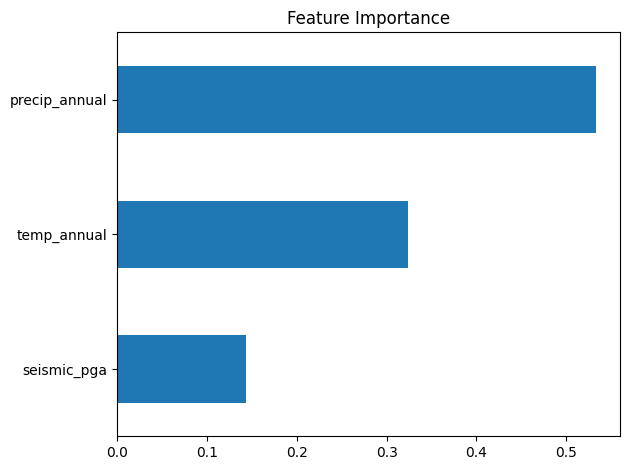

In [ ]:
import rasterio
from rasterio.sample import sample_gen
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score
import matplotlib.pyplot as plt
import sys



hits = pd.read_csv("Meteorite_Landings.csv")
hits.dropna(subset=["GeoLocation", "reclat", "reclong"], inplace=True)
hits.rename(columns={"reclat": "latitude", "reclong": "longitude"}, inplace=True)
hits["label"] = 1
hits = hits.drop(columns=["GeoLocation", "fall"])


n_background = len(hits) * 10
bg = pd.DataFrame({
    "longitude": np.random.uniform(-180, 180, n_background),
    "latitude":  np.random.uniform(-90, 90, n_background),
    "label": 0
})

layers = {
    "seismic_pga":    "v2023_1_pga_475_rock_3min.tif",
    "precip_annual":  "wc2.1_5m_bio_12.tif",
    "temp_annual":    "wc2.1_5m_bio_1.tif",
}

bg_coords = list(zip(bg["longitude"], bg["latitude"]))
bg.replace([np.inf, -np.inf, sys.float_info.max], np.nan, inplace=True)
bg.dropna(inplace=True)


df = pd.concat([hits[["longitude", "latitude", "label"]], bg], ignore_index=True)
coords = list(zip(df["longitude"], df["latitude"]))

for col, path in layers.items():
    with rasterio.open(path) as src:
        values = [v[0] for v in sample_gen(src, coords)]
        nodata = src.nodata
    df[col] = values
    if nodata is not None:
        df[col] = df[col].replace(nodata, np.nan)

df = df.dropna()




df.replace([np.inf, -np.inf, sys.float_info.max], np.nan, inplace=True)
df.dropna(inplace=True)

features = list(layers.keys())
X = df[features]
y = df["label"]
print(X.head())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train_scaled, y_train)

probs = model.predict_proba(X_test_scaled)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.3f}")
print(f"Accuracy: {accuracy_score(y_test, probs > 0.5):.3f}")
print("Classification Report:")
print(classification_report(y_test, probs > 0.5))

importance = pd.Series(model.feature_importances_, index=features).sort_values()
importance.plot(kind="barh", title="Feature Importance")
plt.tight_layout()
plt.show()

To get a continuous score, we can use the `predict_proba` method of the trained model, which returns the probability of each class. The probability for class 1 (meteorite hit) can serve as our suitability score.

In [ ]:
import pandas as pd

def get_meteorite_suitability_score(longitude, latitude, model, scaler, features):
    """
    Predicts the meteorite suitability score (probability) for a given coordinate.

    Args:
        longitude (float): The longitude of the location.
        latitude (float): The latitude of the location.
        model: The trained GradientBoostingClassifier model.
        scaler: The fitted StandardScaler used for feature scaling.
        features (list): List of feature names the model expects (e.g., ['seismic_pga', 'precip_annual', 'temp_annual']).

    Returns:
        float: The probability (score) of the location being good for meteorites.
               Returns None if environmental data cannot be retrieved for the location.
    """

    new_coords_df = pd.DataFrame({
        'longitude': [longitude],
        'latitude': [latitude]
    })


    new_coords_list = [(longitude, latitude)]

    env_features = {}

    global layers

    for col, path in layers.items():
        try:
            with rasterio.open(path) as src:

                value = [v[0] for v in sample_gen(src, new_coords_list)]
                nodata = src.nodata

                if value:
                    current_val = float(value[0])


                    if current_val == sys.float_info.max or (nodata is not None and current_val == nodata):
                        current_val = np.nan

                    if not np.isnan(current_val):
                        env_features[col] = current_val
                    else:
                        print(f"Warning: Could not retrieve valid data for {col} at {longitude}, {latitude}.")
                        return None
                else:

                    print(f"Warning: Could not retrieve data for {col} at {longitude}, {latitude} (empty sample).")
                    return None
        except Exception as e:
            print(f"Error opening or reading raster {path}: {e}")
            return None


    input_data = pd.DataFrame([env_features], columns=features)


    scaled_input_data = scaler.transform(input_data)


    suitability_score = model.predict_proba(scaled_input_data)[:, 1][0]

    return suitability_score


example_longitude = 15.0
example_latitude = 25.0

score = get_meteorite_suitability_score(
    example_longitude, example_latitude, model, scaler, features
)

if score is not None:
    print(f"Meteorite Suitability Score for ({example_longitude}, {example_latitude}): {score:.4f}")
    print("Higher scores indicate a higher predicted likelihood of finding meteorites.")
else:
    print(f"Could not calculate score for ({example_longitude}, {example_latitude}) due to missing environmental data.")

Meteorite Suitability Score for (15.0, 25.0): 0.0867
Higher scores indicate a higher predicted likelihood of finding meteorites.


In [ ]:
import numpy as np
import pandas as pd


min_lon, max_lon = -180, 180
min_lat, max_lat = -90, 90



resolution = 0.5

longitudes = np.arange(min_lon, max_lon + resolution, resolution)
latitudes = np.arange(min_lat, max_lat + resolution, resolution)

heatmap_data = []

print(f"Generating scores for approximately {len(longitudes) * len(latitudes)} points...")

for lat in latitudes:
    for lon in longitudes:
        score = get_meteorite_suitability_score(lon, lat, model, scaler, features)
        if score is not None:
            heatmap_data.append({
                'longitude': lon,
                'latitude': lat,
                'suitability_score': score
            })


heatmap_df = pd.DataFrame(heatmap_data)

output_csv_path = 'meteorite_suitability_heatmap_data.csv'
heatmap_df.to_csv(output_csv_path, index=False)

print(f"Successfully generated heatmap data with {len(heatmap_df)} points and saved to {output_csv_path}")

print("\nFirst 5 rows of the heatmap data:")
display(heatmap_df.head())

Streaming output truncated to the last 5000 lines.
Successfully generated heatmap data with 59662 points and saved to meteorite_suitability_heatmap_data.csv

First 5 rows of the heatmap data:


,longitude,latitude,suitability_score
0,-69.5,-55.5,0.037298
1,-69.0,-55.5,0.039424
2,-68.5,-55.5,0.039424
3,-71.0,-55.0,0.028905
4,-70.5,-55.0,0.033781


In [ ]:
heatmap_df_filtered = heatmap_df.dropna(subset=['suitability_score'])
print(f"Original heatmap_df size: {len(heatmap_df)}")
print(f"Filtered heatmap_df size (after dropping NaN suitability scores): {len(heatmap_df_filtered)}")
display(heatmap_df_filtered.head())
output_csv_path = 'meteorite_suitability_heatmap_data.csv'
heatmap_df.to_csv(output_csv_path, index=False)

Original heatmap_df size: 59662
Filtered heatmap_df size (after dropping NaN suitability scores): 59662


,longitude,latitude,suitability_score
0,-69.5,-55.5,0.037298
1,-69.0,-55.5,0.039424
2,-68.5,-55.5,0.039424
3,-71.0,-55.0,0.028905
4,-70.5,-55.0,0.033781


In [ ]:
df.to_csv('meteorite_and_geography_data.csv')